In [38]:
!pip install wordcloud

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from wordcloud import WordCloud  # Changed 'Wordcloud' to 'wordcloud' - correct capitalization
from collections import Counter
import nltk  # Added missing import for nltk

nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [41]:
df=pd.read_csv("clean_spam.csv")

In [42]:
new_spam = [
    "Congratulations you won $3000 prize",
    "You won a cash reward",
    "Claim your free gift now",
    "You are a lucky winner",
    "Free money waiting for you",
    "Click here to claim your prize",
    "Win a free iPhone today",
    "You have won a lottery",
    "Urgent claim your reward now",
    "Get free cash now",
    "Exclusive offer just for you",
    "You have been selected as a winner",
    "Free voucher available now",
    "Claim your bonus today",
    "Limited time offer click now",
    "Earn money from home",
    "Get your free coupon now",
    "Congratulations your number won",
    "You received a special reward",
    "Hurry free prize waiting",
    "Win $500 instantly",
    "Claim your free ticket",
    "You are our lucky customer",
    "Get rich quickly",
    "Free recharge available",
    "Activate your reward now",
    "Click to receive your gift",
    "Your prize is ready",
    "You won a free vacation",
    "Receive cash bonus now",
    "Call now to claim reward",
    "Free offer expires today",
    "You have a pending reward",
    "Congratulations winner",
    "Win amazing prizes",
    "Get instant cashback",
    "Claim money now",
    "Free deal available",
    "You are selected for a bonus",
    "Unlock your free reward",
    "Special offer for you",
    "You won",
    "Free prize",
    "Claim now",
    "Win cash",
    "Lucky winner",
    "Free gift",
    "Click now",
    "Get reward",
    "Win $1000",
    "Hurry claim"
]


spam_df = pd.DataFrame({
    "Category": ["spam"] * len(new_spam),
    "Message": new_spam
})


# Add to original dataset
df = pd.concat([df, spam_df], ignore_index=True)


# Check new count
print(df['Category'].value_counts())

Category
ham     4516
spam     692
Name: count, dtype: int64


In [43]:
df.tail()

,Category,Message
5203,spam,Free gift
5204,spam,Click now
5205,spam,Get reward
5206,spam,Win $1000
5207,spam,Hurry claim


In [44]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5208 entries, 0 to 5207
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Category  5208 non-null   str  
 1   Message   5208 non-null   str  
dtypes: str(2)
memory usage: 497.5 KB


In [45]:
df.isnull().sum()

Category    0
Message     0
dtype: int64

In [46]:
df.duplicated().sum()

np.int64(0)

In [47]:
df.drop_duplicates(inplace=True)

In [48]:
df

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5203,spam,Free gift
5204,spam,Click now
5205,spam,Get reward
5206,spam,Win $1000


In [49]:
df.to_csv("clean_spam.csv", index=False)

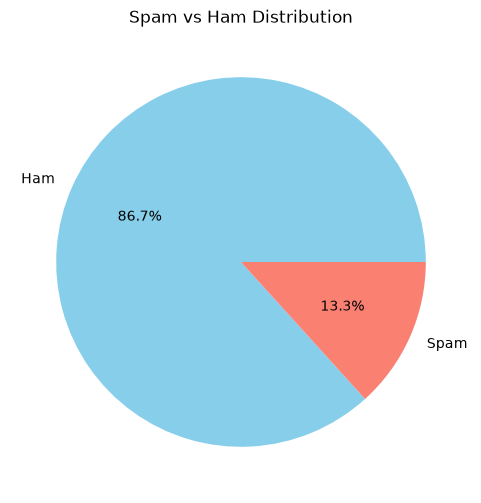

In [50]:
df['Category'].value_counts()

plt.figure(figsize=(6,6))

df['Category'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    labels=['Ham','Spam'],
    colors=['skyblue','salmon']
)

plt.title("Spam vs Ham Distribution")
plt.ylabel("")
plt.show()

In [51]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [52]:
df['num_characters'] = df['Message'].apply(len)

df['num_words'] = df['Message'].apply(lambda x: len(x.split()))

df['num_sentences'] = df['Message'].apply(
    lambda x: len(nltk.sent_tokenize(x))
)

In [53]:
df[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5208.000000,5208.000000,5208.000000
mean,78.533986,15.298003,1.960253
std,58.382427,11.122945,1.451526
min,2.000000,1.000000,1.000000
25%,35.000000,7.000000,1.000000
50%,60.000000,12.000000,1.000000
75%,116.000000,22.000000,2.000000
max,910.000000,171.000000,38.000000


In [54]:
df.groupby('Category')[['num_characters',
                        'num_words',
                        'num_sentences']].mean()

,num_characters,num_words,num_sentences
Category,,,
ham,70.869353,14.239814,1.827724
spam,128.553468,22.203757,2.825145


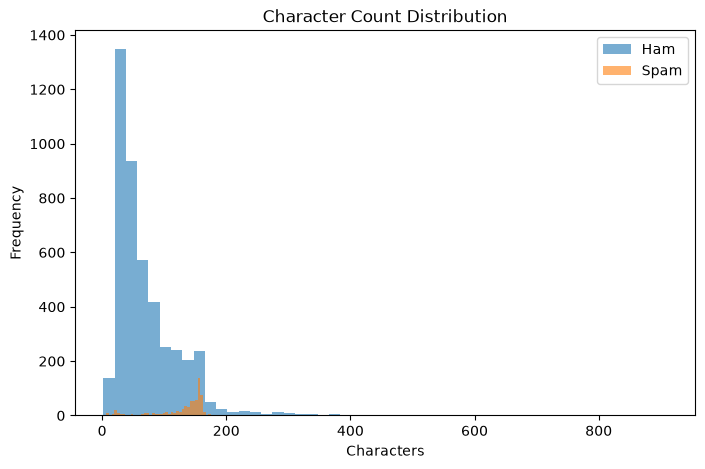

In [55]:
plt.figure(figsize=(8,5))

plt.hist(df[df['Category'] == 'ham']['num_characters'],
         bins=50,
         alpha=0.6,
         label="Ham")

plt.hist(df[df['Category'] == 'spam']['num_characters'],
         bins=50,
         alpha=0.6,
         label="Spam")

plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.title("Character Count Distribution")
plt.legend()

plt.show()

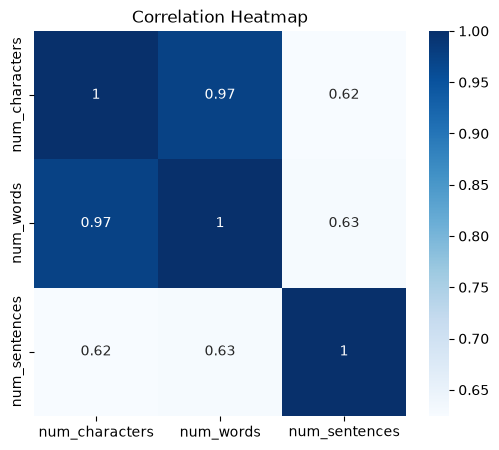

In [56]:
plt.figure(figsize=(6,5))

sns.heatmap(
    df[['num_characters',
        'num_words',
        'num_sentences']].corr(),
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Heatmap")

plt.show()

In [57]:
le = LabelEncoder()
df['Category']=le.fit_transform(df['Category'])
df.head()

,Category,Message,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,20,2
1,0,Ok lar... Joking wif u oni...,29,6,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,28,2
3,0,U dun say so early hor... U c already then say...,49,11,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,13,1


In [58]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(
    num_words=5000,
    lower=True,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(df['Message'])

In [59]:
X = tokenizer.texts_to_sequences(df['Message'])

In [60]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

X = pad_sequences(
    X,
    maxlen=100,
    padding="post",
    truncating="post"
)

In [61]:
y = df['Category']

In [62]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [63]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense

model = Sequential([
    Embedding(input_dim=5000, output_dim=16, input_length=100),
    GlobalAveragePooling1D(),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [64]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [65]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    validation_split=0.2,
)

Epoch 1/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8688 - loss: 0.3932 - val_accuracy: 0.8777 - val_loss: 0.3513
Epoch 2/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8688 - loss: 0.3623 - val_accuracy: 0.8777 - val_loss: 0.3467
Epoch 3/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8688 - loss: 0.3575 - val_accuracy: 0.8777 - val_loss: 0.3408
Epoch 4/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8688 - loss: 0.3446 - val_accuracy: 0.8777 - val_loss: 0.3300
Epoch 5/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8688 - loss: 0.3239 - val_accuracy: 0.8777 - val_loss: 0.3069
Epoch 6/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8688 - loss: 0.2887 - val_accuracy: 0.8765 - val_loss: 0.2729
Epoch 7/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8752 - loss: 0.2415 - val_accuracy: 0.8981 - val_loss: 0.2296
Epoch 8/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9262 - loss: 0.1902 - val_accu

In [66]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9856 - loss: 0.1064
Test Accuracy: 0.9856045842170715


In [70]:
# Take email input from user
email = input("Enter Email: ")

# Convert to sequence
email_seq = tokenizer.texts_to_sequences([email])

# Padding
email_pad = pad_sequences(email_seq, maxlen=100, padding="post")

# Prediction
prediction = model.predict(email_pad)

if prediction[0][0] > 0.5:
    print("\n🚨 Spam Email")
else:
    print("\n✅ Safe (Ham) Email")

print(f"Confidence: {prediction[0][0]:.4f}")

Enter Email:  hi


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step

✅ Safe (Ham) Email
Confidence: 0.0014


In [71]:
model.save("spam_model.keras")

In [72]:
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)